# NB06. Impacto de la Ley de Tolerancia Cero al Alcohol

## Qué analiza este notebook y con qué datos

La Ley de Tolerancia Cero al Alcohol se aprobó el 20 de diciembre de 2024 y
entró en vigencia con su publicación en el Diario Oficial. La fecha cae dentro
de la frontera del split usado en los notebooks anteriores: el modelo se
entrenó con 2022-2024 y se evalúa sobre 2025-2026. El período posterior a la
ley es, en términos del modelo, período no visto.

### Declaración sobre la fuente de datos

El dataset de 89,946 registros individuales que se usa en NB01 a NB05 es
sintético. Está calibrado para reproducir los agregados anuales publicados por
FONAT, pero los registros no son observaciones reales y el cambio normativo no
está codificado en ellos. Buscar el efecto de la ley a nivel de registro
individual devolvería variación del proceso generador, no del fenómeno. Un
resultado obtenido por esa vía sería un artefacto de la simulación presentado
como hallazgo.

Por eso el análisis del impacto de la ley se hace sobre las cifras oficiales
anuales, que sí son datos reales, y no sobre el dataset sintético. La sección 3
documenta esta separación de forma verificable en lugar de dejarla como
afirmación.

### Cifras oficiales FONAT

| Año | Siniestros | Fallecidos |
|-----|-----------:|-----------:|
| 2022 | 17,408 | 1,352 |
| 2023 | 18,463 | 1,256 |
| 2024 | 20,301 | 1,303 |
| 2025 | 22,265 | 1,238 |
| 2026 | 11,509 | 734 |

El registro de 2026 cubre enero a junio. No es comparable contra los años
completos sin un criterio explícito, que se define en la sección 4.

### Qué habilita NB05

NB05 dejó el Random Forest calibrado: la razón entre predicho y observado pasó
de 0.8196 a 1.0057. Con el modelo ajustado se puede construir un pronóstico
contrafactual para 2025-2026, es decir, el nivel de siniestralidad que el
modelo proyecta bajo el supuesto de que las condiciones de 2022-2024 se
mantienen. La comparación entre ese pronóstico y lo efectivamente registrado es
el segundo eje del análisis, junto a la lectura directa de la serie oficial.

### Límites del diseño

La serie oficial tiene tres años previos a la ley y dos posteriores, uno de
ellos incompleto. Con esa cantidad de puntos no hay margen para una regresión
segmentada ni para estimar la tendencia previa con incertidumbre cuantificada.
El análisis es descriptivo y comparativo, no una estimación causal.

La coincidencia entre la entrada en vigencia de la ley y cualquier cambio
observado en la serie no establece causalidad. Sobre el período actúan al menos
el crecimiento del parque vehicular, la trayectoria que la serie ya traía y
posibles cambios en los criterios de registro administrativo. La sección 8
trata estos factores.

## 2. Setup y carga

Se cargan tres cosas, que vienen de orígenes distintos y conviene no mezclar:

1. **Cifras oficiales FONAT.** Se escriben literalmente en el notebook, no se
   leen de un archivo intermedio ni se derivan del dataset. Así cada número
   queda trazable a la fuente publicada y cualquier corrección posterior se
   hace en un solo lugar.
2. **Matriz de frecuencia v2, 676,504 filas.** Grano distrito por fecha por
   franja horaria, con cobertura de 2022-01-01 a 2026-06-30. Se carga para el
   control negativo de la sección 3 y para el pronóstico contrafactual de la
   sección 6. Sus conteos son sintéticos.
3. **Random Forest de frecuencia v2, ajustado en NB05.** Se carga junto a
   `nb05_especificacion_v2.json` y `nb05_metricas.json`. Los parámetros del
   ajuste se leen de esos archivos en lugar de transcribirse, de modo que el
   umbral de detección de la sección 7 quede atado a lo que NB05 efectivamente
   midió y no a una cifra copiada a mano.

Sobre el offset del modelo: `log_exposicion_v2` es el logaritmo de la población
del distrito más un factor de crecimiento interanual compuesto de 7.84% anual.
Ese factor se estimó con las medias anuales de 2022 y 2024, ambas dentro del
conjunto de entrenamiento, así que no incorpora información del período
posterior a la ley. No es una medida de exposición vehicular. Es una
extrapolación de la tendencia que traía la serie, y como tal se usa en la
sección 6.

La columna que alimenta el offset se llama `log_exposicion_v2` en la matriz,
pero el modelo serializado la registró bajo el nombre anterior,
`log_exposicion`. Los valores son los corregidos. Prediciendo sobre el conjunto
de test con cada una de las dos columnas, solo la v2 reproduce las cuatro
cifras que NB05 documentó, media predicha, MAE, RMSE y calibración, con una
diferencia agregada de 3e-6 frente a 0.32 de la columna vieja.

La carga termina con esa misma comprobación, reducida a un control de
procedencia: el modelo cargado debe reproducir la calibración documentada en
`nb05_metricas.json`. Verificar el nombre de la columna no sirve para nada, ya
que se sabe que difiere. Verificar que el pickle predice lo que NB05 dijo que
predecía sí distingue el modelo correcto de cualquier otro que estuviera en
`models/`. Si ese control falla, nada de lo que sigue es válido.

Convención para datos faltantes en todo el notebook: lo que no está disponible
en la fuente queda vacío y anotado como tal. No se imputa, no se interpola y no
se estima a partir de años vecinos.

In [9]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)

# ---------------------------------------------------------------- rutas
p = Path.cwd().resolve()
RAIZ = next((a for a in [p, *p.parents][:5] if (a / "notebooks").is_dir()), p.parent)
DATA, MODELS, RESULTS = RAIZ / "data", RAIZ / "models", RAIZ / "reports" / "results"

# ------------------------------------------------- 1. cifras oficiales FONAT
# Transcritas de la fuente publicada. No se derivan del dataset ni de un
# archivo intermedio. 2026 cubre enero-junio.
OFICIAL = pd.DataFrame(
    [
        (2022, 17408, 1352, "completo"),
        (2023, 18463, 1256, "completo"),
        (2024, 20301, 1303, "completo"),
        (2025, 22265, 1238, "completo"),
        (2026, 11509,  734, "parcial (ene-jun)"),
    ],
    columns=["anio", "siniestros", "fallecidos", "cobertura"],
).set_index("anio")

FECHA_LEY = pd.Timestamp("2024-12-20")  # aprobacion; vigencia con publicacion en D.O.

# ------------------------------------------- 2. metadatos del ajuste de NB05
ESPEC = json.loads((RESULTS / "nb05_especificacion_v2.json").read_text(encoding="utf-8"))
METRICAS = json.loads((RESULTS / "nb05_metricas.json").read_text(encoding="utf-8"))

ESQUEMA = ESPEC["esquema_features"]
COLS_BASE = list(ESQUEMA["features"])          # 8 predictoras, orden normativo
COL_OFFSET_DATOS = ESQUEMA["offset"]           # nombre en la matriz: log_exposicion_v2
SPLIT = ESPEC["split"]
TRAIN_FIN = pd.Timestamp(SPLIT["train"].split(" a ")[1])
TEST_INI, TEST_FIN = (pd.Timestamp(x) for x in SPLIT["test"].split(" a "))

G_ANUAL = ESPEC["correccion_tendencia"]["g_anual"]
REF_RF = METRICAS["tarea_frecuencia"]["modelos"]["random_forest"]
CALIB_RF = METRICAS["calibracion"]["Random Forest Regres"]
SIGMA_RF = METRICAS["validacion"]["sigma_calibracion_rf_v2"]
DERIVA_RF = METRICAS["validacion"]["deriva_18_meses_rf"]

# --------------------------------------------------------- 3. matriz v2
MATRIZ = pd.read_csv(DATA / "processed" / "matriz_frecuencia_v2.csv", parse_dates=["fecha"])
MATRIZ["anio"] = MATRIZ["fecha"].dt.year

# ------------------------------------------------------- 4. modelo RF v2
RF = joblib.load(MODELS / "frecuencia_random_forest_v2.pkl")
COL_OFFSET_MODELO = list(RF.feature_names_in_)[-1]   # nombre heredado: log_exposicion


def construir_X(df: pd.DataFrame) -> pd.DataFrame:
    """Matriz de diseño en el orden que espera el modelo.

    El offset viaja con los valores de COL_OFFSET_DATOS bajo el nombre con el
    que fue entrenado el modelo. Se usa en todas las secciones que predicen.
    """
    X = df[COLS_BASE].copy()
    X[COL_OFFSET_MODELO] = df[COL_OFFSET_DATOS].to_numpy()
    return X[list(RF.feature_names_in_)]


# ------------------------------------- 5. control de procedencia del modelo
# No se compara el nombre de la columna del offset: se sabe que difiere entre
# la matriz y el pickle. Se comprueba que el modelo cargado reproduzca las
# cifras que NB05 documento sobre el conjunto de test.
_test = MATRIZ[MATRIZ["split"] == "test"]
_pred = RF.predict(construir_X(_test))
_obs = _test["n_siniestros"].to_numpy()

proc_calib = float(_pred.sum() / _obs.sum())
proc_media = float(_pred.mean())
procedencia_ok = (abs(proc_calib - CALIB_RF) < 5e-4) and (abs(proc_media - REF_RF["media_predicha"]) < 1e-4)

print(f"raiz              : {RAIZ.name}")
print(f"matriz            : {MATRIZ.shape[0]:,} filas x {MATRIZ.shape[1]} columnas")
print(f"cobertura         : {MATRIZ['fecha'].min():%Y-%m-%d} a {MATRIZ['fecha'].max():%Y-%m-%d}")
print(f"split train       : hasta {TRAIN_FIN:%Y-%m-%d}")
print(f"split test        : {TEST_INI:%Y-%m-%d} a {TEST_FIN:%Y-%m-%d}  ({len(_test):,} filas)")
print(f"ley (aprobacion)  : {FECHA_LEY:%Y-%m-%d}")
print(f"offset            : {COL_OFFSET_DATOS} en la matriz, '{COL_OFFSET_MODELO}' en el modelo")
print(f"                    CAGR {G_ANUAL:.4%} anual, estimado solo con train")
print(f"modelo            : {type(RF).__name__}, {RF.n_estimators} arboles, {RF.n_features_in_} features")

print(f"\nControl de procedencia (predicho vs. lo documentado en nb05_metricas.json):")
print(f"  calibracion  obtenida {proc_calib:.6f}   documentada {CALIB_RF}")
print(f"  media pred.  obtenida {proc_media:.6f}   documentada {REF_RF['media_predicha']}")
print(f"  resultado    : {'PASA' if procedencia_ok else 'FALLA, detener'}")

print("\nParametros de NB05 que fijan el umbral de deteccion de la seccion 7:")
print(f"  sigma de calibracion : {SIGMA_RF}")
print(f"  deriva a 18 meses    : {DERIVA_RF}")

print("\nCifras oficiales FONAT:")
print(OFICIAL.to_string())

raiz              : siniestralidad-vial-sv
matriz            : 676,504 filas x 25 columnas
cobertura         : 2022-01-01 a 2026-06-30
split train       : hasta 2024-12-31
split test        : 2025-01-01 a 2026-06-30  (224,952 filas)
ley (aprobacion)  : 2024-12-20
offset            : log_exposicion_v2 en la matriz, 'log_exposicion' en el modelo
                    CAGR 7.8426% anual, estimado solo con train
modelo            : RandomForestRegressor, 200 arboles, 9 features

Control de procedencia (predicho vs. lo documentado en nb05_metricas.json):
  calibracion  obtenida 1.005698   documentada 1.0057
  media pred.  obtenida 0.150994   documentada 0.150994
  resultado    : PASA

Parametros de NB05 que fijan el umbral de deteccion de la seccion 7:
  sigma de calibracion : 0.04
  deriva a 18 meses    : -0.0432

Cifras oficiales FONAT:
      siniestros  fallecidos          cobertura
anio                                           
2022       17408        1352           completo
2023       1

## 3. Control negativo sobre el dataset sintético

La sección 1 afirma que el quiebre normativo no está dentro de los 89,946
registros. Una afirmación así no se sostiene sola, porque el lector no tiene
cómo distinguirla de una excusa para no buscar. Esta sección la convierte en
algo comprobable.

### La fecha de entrada en vigencia no es una sola

La reforma se aprobó el 20 de diciembre de 2024. El ejemplar del Diario Oficial
que la contiene lleva esa misma fecha impresa, pero circuló varios días después,
entre el 26 y el 28 de diciembre según la fuente. El decreto fijó vigencia al
día siguiente de la publicación, el 29 de diciembre. El artículo 140 de la
Constitución exige que una ley sea obligatoria al menos ocho días después de su
publicación, lo que llevaría la vigencia al 5 de enero de 2025. La discrepancia
fue objeto de disputa pública y no está resuelta.

Se trabaja entonces con cuatro fechas candidatas y no con una. Ninguna se
descarta y ninguna se promedia.

El límite entre años calendario, 1 de enero de 2025, cae dentro de ese rango. Y
ese límite es el punto donde cambia el nivel al que fue calibrado el generador
sintético. Las dos cosas quedan superpuestas por menos de dos semanas, de modo
que a grano diario no se pueden separar dentro de esta matriz.

### Qué se verifica

**Primera, qué nivel de información contiene la matriz.** Se comparan las sumas
anuales de `n_siniestros` y `fallecidos` contra las cifras FONAT. El resultado
define el alcance de todo lo que sigue: si los totales anuales coinciden, la
matriz reproduce la serie oficial a nivel de año y nada por debajo de eso, y la
sección 7 puede tender el puente entre la salida del modelo y las cifras
publicadas. Si no coinciden, ese puente no existe y la sección 7 cambia de
forma.

**Segunda, dónde cae cualquier discontinuidad.** Se mide el promedio diario de
siniestros en ventanas simétricas alrededor de cada fecha candidata y alrededor
del 1 de enero de 2025, por separado. Dada la superposición descrita arriba, la
prueba no puede atribuir un salto a una u otra causa. Lo que sí puede
establecer es la magnitud del cambio de nivel y si está concentrado en un día o
repartido sobre el rango.

**Tercera, si el mismo patrón aparece donde no hay ley.** Se repite la medición
en las fechas placebo 2022-12-20 y 2023-12-20, con ventanas del mismo ancho. Un
cambio de nivel a fin de año puede venir de estacionalidad, de feriados o del
factor de crecimiento mensual del generador, y ninguna de esas cosas tiene que
ver con la norma. La comparación contra las placebo es lo que da escala a
cualquier cosa que se observe en el corte real.

### Cómo se lee

Las tres lecturas se interpretan juntas y ninguna mide el efecto de la ley.
Sirven para una sola decisión: si la microdata contiene algo que las secciones
5 a 7 deban usar, o si el análisis tiene que apoyarse enteramente en la serie
oficial anual. Cualquier lectura de estos números en clave de impacto normativo
sería un error de interpretación, porque el generador no tiene ninguna variable
que codifique la norma.

In [10]:
# ------------------------------------------------- 3.1 nivel de la matriz
ANUAL = MATRIZ.groupby("anio").agg(
    siniestros_matriz=("n_siniestros", "sum"),
    fallecidos_matriz=("fallecidos", "sum"),
    dias=("fecha", "nunique"),
)
COMP = ANUAL.join(OFICIAL[["siniestros", "fallecidos", "cobertura"]])
COMP["ratio_sin"] = COMP["siniestros_matriz"] / COMP["siniestros"]
COMP["ratio_fal"] = COMP["fallecidos_matriz"] / COMP["fallecidos"]

print("3.1  Sumas anuales de la matriz contra las cifras FONAT")
print(COMP[["siniestros_matriz", "siniestros", "ratio_sin",
            "fallecidos_matriz", "fallecidos", "ratio_fal",
            "dias", "cobertura"]].to_string(float_format=lambda v: f"{v:.4f}"))

coincide_anual = bool(
    np.allclose(COMP["ratio_sin"], 1.0, atol=1e-6)
    and np.allclose(COMP["ratio_fal"], 1.0, atol=1e-6)
)
print(f"\ncoincidencia exacta en los cinco periodos: {coincide_anual}")

# --------------------------------------------- 3.2 ventanas alrededor del corte
DIARIO = MATRIZ.groupby("fecha").agg(
    siniestros=("n_siniestros", "sum"),
    fallecidos=("fallecidos", "sum"),
)

FECHAS = {
    "aprobacion / fecha impresa D.O.": "2024-12-20",
    "circulacion D.O. (version 26)":   "2024-12-26",
    "circulacion D.O. (version 28)":   "2024-12-28",
    "vigencia segun decreto":          "2024-12-29",
    "limite de calibracion anual":     "2025-01-01",
    "vigencia segun art. 140 Cn.":     "2025-01-05",
    "placebo 2022":                    "2022-12-20",
    "placebo 2023":                    "2023-12-20",
}


def ventana(serie: pd.Series, fecha: str, w: int):
    """Promedio diario en [d-w, d-1] y [d, d+w-1]. None si la ventana no cabe."""
    d = pd.Timestamp(fecha)
    pre = serie.loc[d - pd.Timedelta(days=w): d - pd.Timedelta(days=1)]
    post = serie.loc[d: d + pd.Timedelta(days=w - 1)]
    if len(pre) < w or len(post) < w:
        return None
    return float(pre.mean()), float(post.mean())


filas = []
for w in (30, 90):
    for etiqueta, fecha in FECHAS.items():
        r = ventana(DIARIO["siniestros"], fecha, w)
        if r is None:
            filas.append({"ventana_dias": w, "corte": etiqueta, "fecha": fecha,
                          "pre": np.nan, "post": np.nan, "delta_pct": np.nan,
                          "nota": "ventana incompleta, no se estima"})
        else:
            pre, post = r
            filas.append({"ventana_dias": w, "corte": etiqueta, "fecha": fecha,
                          "pre": pre, "post": post,
                          "delta_pct": 100 * (post - pre) / pre, "nota": ""})

VENTANAS = pd.DataFrame(filas)
print("\n\n3.2  Promedio diario de siniestros antes y despues de cada corte")
for w in (30, 90):
    sub = VENTANAS[VENTANAS["ventana_dias"] == w].drop(columns="ventana_dias")
    print(f"\n--- ventana de +/- {w} dias ---")
    print(sub.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

# ------------------------------------- 3.3 los predictores no codifican la norma
# Si ninguna feature cambia de nivel en el corte, el modelo no tiene por donde
# enterarse de la ley. Se mide sobre la ventana de 90 dias del limite anual.
d0 = pd.Timestamp("2025-01-01")
pre_m = MATRIZ[(MATRIZ["fecha"] >= d0 - pd.Timedelta(days=90)) & (MATRIZ["fecha"] < d0)]
post_m = MATRIZ[(MATRIZ["fecha"] >= d0) & (MATRIZ["fecha"] < d0 + pd.Timedelta(days=90))]

cols_chequeo = COLS_BASE + ["factor_crec", COL_OFFSET_DATOS]
FEATS = pd.DataFrame({
    "media_pre_90d": pre_m[cols_chequeo].mean(),
    "media_post_90d": post_m[cols_chequeo].mean(),
})
FEATS["delta_pct"] = 100 * (FEATS["media_post_90d"] - FEATS["media_pre_90d"]) / FEATS["media_pre_90d"].replace(0, np.nan)

print("\n\n3.3  Nivel de los predictores a ambos lados del 2025-01-01")
print(FEATS.to_string(float_format=lambda v: f"{v:12.6f}"))
print("\nNinguna columna de la matriz codifica la norma. Las que se mueven lo")
print("hacen por calendario, clima o por el factor de crecimiento del generador.")

3.1  Sumas anuales de la matriz contra las cifras FONAT
      siniestros_matriz  siniestros  ratio_sin  fallecidos_matriz  fallecidos  ratio_fal  dias          cobertura
anio                                                                                                             
2022              17408       17408     1.0000               1352        1352     1.0000   365           completo
2023              18463       18463     1.0000               1256        1256     1.0000   365           completo
2024              20301       20301     1.0000               1303        1303     1.0000   366           completo
2025              22265       22265     1.0000               1238        1238     1.0000   365           completo
2026              11509       11509     1.0000                734         734     1.0000   181  parcial (ene-jun)

coincidencia exacta en los cinco periodos: True


3.2  Promedio diario de siniestros antes y despues de cada corte

--- ventana de +/- 30 dias --

In [11]:
# ------------------------------------------------- 3.1 nivel de la matriz
ANUAL = MATRIZ.groupby("anio").agg(
    siniestros_matriz=("n_siniestros", "sum"),
    fallecidos_matriz=("fallecidos", "sum"),
    dias=("fecha", "nunique"),
)
COMP = ANUAL.join(OFICIAL[["siniestros", "fallecidos", "cobertura"]])
COMP["ratio_sin"] = COMP["siniestros_matriz"] / COMP["siniestros"]
COMP["ratio_fal"] = COMP["fallecidos_matriz"] / COMP["fallecidos"]

print("3.1  Sumas anuales de la matriz contra las cifras FONAT")
print(COMP[["siniestros_matriz", "siniestros", "ratio_sin",
            "fallecidos_matriz", "fallecidos", "ratio_fal",
            "dias", "cobertura"]].to_string(float_format=lambda v: f"{v:.4f}"))

coincide_anual = bool(
    np.allclose(COMP["ratio_sin"], 1.0, atol=1e-6)
    and np.allclose(COMP["ratio_fal"], 1.0, atol=1e-6)
)
print(f"\ncoincidencia exacta en los cinco periodos: {coincide_anual}")

# --------------------------------------------- 3.2 ventanas alrededor del corte
DIARIO = MATRIZ.groupby("fecha").agg(
    siniestros=("n_siniestros", "sum"),
    fallecidos=("fallecidos", "sum"),
)

FECHAS = {
    "aprobacion / fecha impresa D.O.": "2024-12-20",
    "circulacion D.O. (version 26)":   "2024-12-26",
    "circulacion D.O. (version 28)":   "2024-12-28",
    "vigencia segun decreto":          "2024-12-29",
    "limite de calibracion anual":     "2025-01-01",
    "vigencia segun art. 140 Cn.":     "2025-01-05",
    "placebo 2022":                    "2022-12-20",
    "placebo 2023":                    "2023-12-20",
}


def ventana(serie: pd.Series, fecha: str, w: int):
    """Promedio diario en [d-w, d-1] y [d, d+w-1]. None si la ventana no cabe."""
    d = pd.Timestamp(fecha)
    pre = serie.loc[d - pd.Timedelta(days=w): d - pd.Timedelta(days=1)]
    post = serie.loc[d: d + pd.Timedelta(days=w - 1)]
    if len(pre) < w or len(post) < w:
        return None
    return float(pre.mean()), float(post.mean())


filas = []
for w in (30, 90):
    for etiqueta, fecha in FECHAS.items():
        r = ventana(DIARIO["siniestros"], fecha, w)
        if r is None:
            filas.append({"ventana_dias": w, "corte": etiqueta, "fecha": fecha,
                          "pre": np.nan, "post": np.nan, "delta_pct": np.nan,
                          "nota": "ventana incompleta, no se estima"})
        else:
            pre, post = r
            filas.append({"ventana_dias": w, "corte": etiqueta, "fecha": fecha,
                          "pre": pre, "post": post,
                          "delta_pct": 100 * (post - pre) / pre, "nota": ""})

VENTANAS = pd.DataFrame(filas)
print("\n\n3.2  Promedio diario de siniestros antes y despues de cada corte")
for w in (30, 90):
    sub = VENTANAS[VENTANAS["ventana_dias"] == w].drop(columns="ventana_dias")
    print(f"\n--- ventana de +/- {w} dias ---")
    print(sub.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

# ------------------------------------- 3.3 los predictores no codifican la norma
# Si ninguna feature cambia de nivel en el corte, el modelo no tiene por donde
# enterarse de la ley. Se mide sobre la ventana de 90 dias del limite anual.
d0 = pd.Timestamp("2025-01-01")
pre_m = MATRIZ[(MATRIZ["fecha"] >= d0 - pd.Timedelta(days=90)) & (MATRIZ["fecha"] < d0)]
post_m = MATRIZ[(MATRIZ["fecha"] >= d0) & (MATRIZ["fecha"] < d0 + pd.Timedelta(days=90))]

cols_chequeo = COLS_BASE + ["factor_crec", COL_OFFSET_DATOS]
FEATS = pd.DataFrame({
    "media_pre_90d": pre_m[cols_chequeo].mean(),
    "media_post_90d": post_m[cols_chequeo].mean(),
})
FEATS["delta_pct"] = 100 * (FEATS["media_post_90d"] - FEATS["media_pre_90d"]) / FEATS["media_pre_90d"].replace(0, np.nan)

print("\n\n3.3  Nivel de los predictores a ambos lados del 2025-01-01")
print(FEATS.to_string(float_format=lambda v: f"{v:12.6f}"))
print("\nNinguna columna de la matriz codifica la norma. Las que se mueven lo")
print("hacen por calendario, clima o por el factor de crecimiento del generador.")

3.1  Sumas anuales de la matriz contra las cifras FONAT
      siniestros_matriz  siniestros  ratio_sin  fallecidos_matriz  fallecidos  ratio_fal  dias          cobertura
anio                                                                                                             
2022              17408       17408     1.0000               1352        1352     1.0000   365           completo
2023              18463       18463     1.0000               1256        1256     1.0000   365           completo
2024              20301       20301     1.0000               1303        1303     1.0000   366           completo
2025              22265       22265     1.0000               1238        1238     1.0000   365           completo
2026              11509       11509     1.0000                734         734     1.0000   181  parcial (ene-jun)

coincidencia exacta en los cinco periodos: True


3.2  Promedio diario de siniestros antes y despues de cada corte

--- ventana de +/- 30 dias --

### 3.4 La misma prueba sin el escalón anual

La prueba anterior mezcla dos cosas. Las ventanas que cruzan el 1 de enero
toman días de dos años calibrados a niveles distintos, y parte de la diferencia
entre el promedio previo y el posterior viene de ese cambio de nivel, no de lo
que ocurra alrededor del corte. El efecto es mayor cuanto más desplazada esté
la fecha respecto del límite de año, que es justo la situación de las fechas
candidatas del 20 y el 26 de diciembre.

Para separarlo se normaliza cada día dividiéndolo por el promedio diario de su
propio año. La serie resultante conserva la estructura intra-anual completa,
estacionalidad, feriados, día de semana y clima, y pierde el escalón entre
años. Sobre ella se repiten las mismas ventanas, en las mismas fechas
candidatas y en los mismos placebos.

La pregunta que responde es concreta: una vez descontado el nivel anual, ¿queda
algún cambio de régimen alrededor del corte que no aparezca también en las
fechas placebo?

Las ventanas usadas tocan únicamente los años 2022 a 2025, todos completos. El
período parcial de 2026 no entra en ninguna, así que la normalización no se ve
afectada por su cobertura de medio año.

Si el corte real queda dentro del rango que abarcan los placebos, la microdata
no contiene un quiebre sub-anual y el análisis se apoya enteramente en la serie
oficial, como anticipó la sección 1. Si queda fuera, hay algo en el generador
que no está documentado y habría que entenderlo antes de escribir las secciones
5 a 7.

In [12]:
# ---------------------------------- serie normalizada por el nivel anual
anio_de_dia = DIARIO.index.year
media_anual = DIARIO.groupby(anio_de_dia)["siniestros"].transform("mean")
NORM = DIARIO["siniestros"] / media_anual

print("Promedio diario por anio usado como divisor:")
print(DIARIO.groupby(anio_de_dia)["siniestros"].mean().to_string(float_format=lambda v: f"{v:.4f}"))
print("(2026 cubre 181 dias, su divisor no es un promedio anual completo)\n")

FECHAS_34 = dict(FECHAS)
FECHAS_34["placebo 2025 (post-ley)"] = "2025-12-20"

filas = []
for w in (30, 90):
    for etiqueta, fecha in FECHAS_34.items():
        r = ventana(NORM, fecha, w)
        d = pd.Timestamp(fecha)
        toca_2026 = (d + pd.Timedelta(days=w - 1)).year == 2026
        if r is None:
            filas.append({"w": w, "corte": etiqueta, "fecha": fecha, "pre": np.nan,
                          "post": np.nan, "delta_pct": np.nan, "nota": "ventana incompleta"})
        else:
            pre, post = r
            filas.append({"w": w, "corte": etiqueta, "fecha": fecha, "pre": pre, "post": post,
                          "delta_pct": 100 * (post - pre) / pre,
                          "nota": "toca 2026 parcial" if toca_2026 else ""})

NORMV = pd.DataFrame(filas)
print("3.4  Ventanas sobre la serie normalizada por nivel anual")
for w in (30, 90):
    sub = NORMV[NORMV["w"] == w].drop(columns="w")
    print(f"\n--- ventana de +/- {w} dias ---")
    print(sub.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

# ------------------------- distribucion empirica sobre todas las fechas de corte
# Solo cortes cuyas dos ventanas caen enteras dentro de 2022-2025, para que el
# periodo parcial de 2026 no entre en la referencia.
LIM_INI, LIM_FIN = pd.Timestamp("2022-01-01"), pd.Timestamp("2025-12-31")

def distribucion(w: int) -> pd.Series:
    vals = {}
    for d in pd.date_range(LIM_INI + pd.Timedelta(days=w), LIM_FIN - pd.Timedelta(days=w - 1)):
        r = ventana(NORM, d, w)
        if r is not None:
            pre, post = r
            vals[d] = 100 * (post - pre) / pre
    return pd.Series(vals)

print("\n\nUbicacion de cada corte en la distribucion de todas las fechas posibles")
for w in (30, 90):
    dist = distribucion(w)
    print(f"\n--- ventana de +/- {w} dias  (n = {len(dist):,} fechas de corte) ---")
    print(f"    media {dist.mean():+.4f}   desvio {dist.std():.4f}   "
          f"p05 {dist.quantile(.05):+.4f}   p50 {dist.quantile(.50):+.4f}   p95 {dist.quantile(.95):+.4f}")
    ref = []
    for etiqueta, fecha in FECHAS_34.items():
        d = pd.Timestamp(fecha)
        if d not in dist.index:
            ref.append({"corte": etiqueta, "fecha": fecha, "delta_pct": np.nan,
                        "percentil": np.nan, "z": np.nan, "nota": "fuera del rango de referencia"})
            continue
        v = dist.loc[d]
        ref.append({"corte": etiqueta, "fecha": fecha, "delta_pct": v,
                    "percentil": 100 * (dist < v).mean(),
                    "z": (v - dist.mean()) / dist.std(), "nota": ""})
    print(pd.DataFrame(ref).to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

# Rango que abarcan los placebos, como referencia directa
for w in (30, 90):
    sub = NORMV[(NORMV["w"] == w) & (NORMV["corte"].str.startswith("placebo"))]["delta_pct"].dropna()
    cand = NORMV[(NORMV["w"] == w) & (~NORMV["corte"].str.startswith("placebo"))][["corte", "delta_pct"]].dropna()
    if len(sub):
        lo, hi = sub.min(), sub.max()
        print(f"\n--- ventana +/- {w} dias: rango de placebos [{lo:+.4f}, {hi:+.4f}] ---")
        for _, row in cand.iterrows():
            dentro = lo <= row["delta_pct"] <= hi
            print(f"  {row['corte']:34s} {row['delta_pct']:+9.4f}  {'dentro' if dentro else 'FUERA'}")

Promedio diario por anio usado como divisor:
fecha
2022   47.6932
2023   50.5836
2024   55.4672
2025   61.0000
2026   63.5856
(2026 cubre 181 dias, su divisor no es un promedio anual completo)

3.4  Ventanas sobre la serie normalizada por nivel anual

--- ventana de +/- 30 dias ---
                          corte      fecha       pre      post  delta_pct              nota
aprobacion / fecha impresa D.O. 2024-12-20    0.9591    0.9702     1.1583                  
  circulacion D.O. (version 26) 2024-12-26    0.9513    0.9466    -0.4991                  
  circulacion D.O. (version 28) 2024-12-28    0.9808    0.9239    -5.8025                  
         vigencia segun decreto 2024-12-29    0.9928    0.9191    -7.4209                  
    limite de calibracion anual 2025-01-01    0.9952    0.9066    -8.9054                  
    vigencia segun art. 140 Cn. 2025-01-05    0.9928    0.9066    -8.6875                  
                   placebo 2022 2022-12-20    0.9694    0.9392    -3.1187

### 3.5 Resultado del control negativo

Las sumas anuales de la matriz reproducen las cifras FONAT con razón 1.0000 en
los cinco períodos, siniestros y fallecidos. La matriz está calibrada al nivel
anual de la serie oficial y a nada por debajo de ese nivel. El puente entre la
salida del modelo y las cifras publicadas, que la sección 7 necesita, existe.

Sobre la serie normalizada por el nivel anual, ninguna de las seis fechas
candidatas se separa de los placebos. En la ventana de noventa días las
candidatas caen entre z = -1.32 y z = -1.41 contra la distribución de las 1,282
fechas de corte posibles, y el placebo de 2023 está en z = -1.40. En la ventana
de treinta días las candidatas ocupan del percentil 10 al 49 y los dos placebos
comparables el 9.3 y el 31.1, cubriendo el mismo rango. Los cortes de fin de
año, reales y placebo por igual, caen en la cola baja de la distribución, que
es lo que produce la caída estacional de diciembre.

Un criterio de mínimo y máximo sobre tres placebos no sirve para decidir esto.
Las diferencias que ese criterio marca son de 0.06 y 0.11 puntos porcentuales
contra un desvío de 9.98 en la distribución de referencia, y cambian de signo
según el ancho de ventana. La lectura se hace contra la distribución completa.

Ninguna de las ocho columnas predictoras cambia de nivel en el corte por algo
distinto de calendario, clima o el factor de crecimiento del generador. El
generador no tiene ninguna variable que codifique la norma, y la prueba
empírica es consistente con eso.

Queda establecido entonces lo que la sección 1 declaró: el efecto de la ley no
está dentro de los registros individuales, y las secciones 5 a 7 se apoyan en
la serie oficial anual y en el pronóstico del modelo, no en la microdata.

Dos límites que esta sección no resuelve y que arrastra el resto del notebook.
El primero es que la fecha de entrada en vigencia y el límite de calibración
anual están separados por menos de dos semanas, de modo que a grano diario no
se pueden distinguir ni acá ni más adelante. El segundo, y más importante: que
la microdata no contenga el quiebre no dice nada sobre si la ley tuvo efecto.
Dice que este dataset no puede responder esa pregunta. La respuesta, en la
medida en que estos datos permitan alguna, sale de las secciones que siguen.

## 4. Serie oficial: construcción y normalización

Esta sección arma la serie sobre la que trabajan las secciones 5 a 7. Son las
cifras FONAT y nada más. La matriz sintética no participa acá.

### Letalidad

A las dos series publicadas se les agrega una tercera derivada, la letalidad,
definida como fallecidos sobre siniestros. Las dos series oficiales pueden
moverse en direcciones distintas, y la letalidad es lo que capta esa diferencia
en un solo número. Además es un cociente entre dos cantidades que provienen del
mismo registro, así que es menos sensible que los niveles a cambios en la
cobertura o en los criterios de captura administrativa.

### Períodos

El corte se ubica entre 2024 y 2025. Todas las fechas candidatas de entrada en
vigencia caen en los últimos doce días de 2024 o los primeros cinco de 2025, de
modo que la partición en años es la misma bajo cualquiera de ellas: 2022, 2023
y 2024 del lado previo, 2025 y 2026 del lado posterior. Es la única decisión de
diseño del notebook que no depende de resolver la disputa sobre la fecha de
vigencia.

### Tratamiento del año parcial

El registro de 2026 cubre 181 días, de enero a junio. No se anualiza, no se
proyecta y no se interpola.

Para los niveles de siniestros y fallecidos, 2026 no se compara contra años
completos. La comparación queda vacía y anotada. Tampoco se resuelve tomando el
primer semestre de los años previos de la matriz sintética: la matriz reproduce
los totales anuales oficiales, pero su distribución dentro del año es la del
generador, no la del registro real, y un semestre extraído de ahí no es un dato
oficial.

Para la letalidad, el cociente sí se calcula sobre los 181 días, con un
supuesto que conviene dejar escrito porque no es gratuito: que la severidad de
los siniestros del primer semestre representa la del año. El período agostino
cae en el segundo semestre, y es precisamente el tramo del calendario donde
este proyecto sostiene que la siniestralidad se comporta distinto. La letalidad
de 2026 se reporta entonces marcada como parcial, y no se usa para cerrar
ninguna conclusión.

### Tasas por habitante

Una tasa por cada cien mil habitantes solo aporta si existe una serie de
población anual. El código verifica si la matriz contiene población variable
por año. Si la población está fijada a un único valor por distrito para todo el
período, la tasa sería la serie de siniestros multiplicada por una constante,
no agregaría información, y se omite dejando anotado el motivo y la fuente que
haría falta.

In [13]:
# --------------------------------------------- 4.1 serie oficial y letalidad
SERIE = OFICIAL.copy()
SERIE["letalidad_pct"] = 100 * SERIE["fallecidos"] / SERIE["siniestros"]
SERIE["periodo"] = np.where(SERIE.index <= 2024, "pre", "post")
SERIE["dias_cobertura"] = [365, 365, 366, 365, 181]
SERIE["nivel_comparable"] = SERIE["cobertura"].eq("completo")

# Los niveles del anio parcial no se comparan: quedan vacios y anotados.
SERIE["siniestros_comparables"] = SERIE["siniestros"].where(SERIE["nivel_comparable"])
SERIE["fallecidos_comparables"] = SERIE["fallecidos"].where(SERIE["nivel_comparable"])
SERIE["letalidad_nota"] = np.where(SERIE["nivel_comparable"], "", "parcial ene-jun")

print("4.1  Serie oficial FONAT")
print(SERIE[["siniestros", "fallecidos", "letalidad_pct", "letalidad_nota",
             "periodo", "dias_cobertura"]].to_string(float_format=lambda v: f"{v:9.4f}"))

print("\nNiveles admitidos para comparacion entre anios:")
print(SERIE[["siniestros_comparables", "fallecidos_comparables"]].to_string(
    float_format=lambda v: f"{v:12.0f}", na_rep="vacio (no comparable)"))

# ------------------------------------------- 4.2 particion bajo cada candidata
print("\n\n4.2  Particion pre/post bajo cada fecha candidata de vigencia")
for etiqueta, fecha in FECHAS.items():
    if etiqueta.startswith("placebo") or etiqueta.startswith("limite"):
        continue
    d = pd.Timestamp(fecha)
    anios_pre = [a for a in SERIE.index if a < d.year or (a == d.year and d.month == 12)]
    anios_post = [a for a in SERIE.index if a not in anios_pre]
    print(f"  {etiqueta:34s} {fecha}   pre={anios_pre}  post={anios_post}")

particiones = set()
for etiqueta, fecha in FECHAS.items():
    if etiqueta.startswith("placebo") or etiqueta.startswith("limite"):
        continue
    d = pd.Timestamp(fecha)
    particiones.add(tuple(a for a in SERIE.index if a < d.year or (a == d.year and d.month == 12)))
print(f"\n  particiones distintas resultantes: {len(particiones)}  -> "
      f"{'la eleccion de fecha no altera la particion anual' if len(particiones) == 1 else 'la eleccion de fecha SI altera la particion'}")

# ------------------------------------------- 4.3 disponibilidad de poblacion
pob_anual = (MATRIZ.drop_duplicates(subset=["anio", "distrito_key"])
                   .groupby("anio")["poblacion"].sum())
distritos = MATRIZ["distrito_key"].nunique()
pob_varia = bool(pob_anual.nunique() > 1)

print("\n\n4.3  Poblacion en la matriz")
print(f"  distritos: {distritos}")
print(pob_anual.to_string(float_format=lambda v: f"{v:,.0f}"))
print(f"\n  la poblacion varia entre anios: {pob_varia}")

if pob_varia:
    SERIE["tasa_100k"] = 100_000 * SERIE["siniestros"] / pob_anual.reindex(SERIE.index)
    SERIE["mortalidad_100k"] = 100_000 * SERIE["fallecidos"] / pob_anual.reindex(SERIE.index)
    print("\n  tasas por 100 mil habitantes:")
    print(SERIE[["tasa_100k", "mortalidad_100k"]].to_string(float_format=lambda v: f"{v:9.4f}"))
else:
    SERIE["tasa_100k"] = pd.NA
    SERIE["mortalidad_100k"] = pd.NA
    print("\n  Poblacion fija para todo el periodo. Una tasa por 100 mil seria la serie")
    print("  de siniestros reescalada por una constante y no agregaria informacion.")
    print("  Columnas dejadas vacias. Fuente faltante: proyecciones de poblacion")
    print("  anuales por distrito (DIGESTYC / BCR).")



4.1  Serie oficial FONAT
      siniestros  fallecidos  letalidad_pct   letalidad_nota periodo  dias_cobertura
anio                                                                                
2022       17408        1352         7.7665                      pre             365
2023       18463        1256         6.8028                      pre             365
2024       20301        1303         6.4184                      pre             366
2025       22265        1238         5.5603                     post             365
2026       11509         734         6.3776  parcial ene-jun    post             181

Niveles admitidos para comparacion entre anios:
      siniestros_comparables  fallecidos_comparables
anio                                                
2022                   17408                    1352
2023                   18463                    1256
2024                   20301                    1303
2025                   22265                    1238
2026   vacio 

## 5. Variación observada

Dos lecturas sobre la serie oficial. La primera es la variación interanual
simple. La segunda compara lo registrado en el período posterior contra la
prolongación de la trayectoria que traían los tres años previos.

### Cómo se estima la trayectoria previa

Hay tres años antes del corte. Con tres puntos no se puede estimar una
tendencia con incertidumbre cuantificada, así que no se reportan intervalos de
confianza ni pruebas de significancia: serían decorativos.

Tampoco tiene sentido comparar métodos de ajuste. Con tres años equiespaciados,
una recta ajustada por mínimos cuadrados sobre los logaritmos devuelve la misma
pendiente que unir el primer año con el último, porque el año del medio cae en
el centroide de las abscisas y no interviene en el cálculo de la pendiente. Son
el mismo número escrito de dos maneras.

Lo que sí informa es la tasa que implica cada par de años por separado: la de
2022 a 2023, la de 2023 a 2024, y la de 2022 a 2024 que promedia
geométricamente a las dos anteriores. Si las tres están cerca, la serie viene
creciendo a ritmo parejo y prolongarla es defendible. Si están dispersas, la
trayectoria previa no es una sola cosa y cualquier proyección hereda esa
dispersión. El rango que abarcan las tres tasas es lo que se reporta, y la
proyección del período posterior se calcula bajo cada una de ellas en lugar de
bajo un único valor.

La forma funcional elegida es crecimiento geométrico, es decir, una tasa
constante por año. Es la misma forma que usa la corrección de exposición
ajustada en NB05, lo que mantiene las dos partes del notebook sobre el mismo
supuesto. Para una serie de conteos que crece con la población y el parque
vehicular es una elección razonable, pero es una elección, no un hecho de los
datos.

### Qué se compara y qué queda afuera

Para siniestros y fallecidos, la comparación de niveles corre sobre 2025
únicamente. El registro de 2026 cubre medio año y no entra, como se estableció
al construir la serie.

Para la letalidad, que es un cociente, se calcula también 2026, marcado como
parcial. El supuesto de que la severidad del primer semestre representa la del
año queda arrastrado en esa cifra y no se despeja acá.

### La figura

Se produce `nb06_01_serie_oficial.png` con tres paneles apilados sobre el mismo
eje de años: siniestros, fallecidos y letalidad. Cada panel lleva una sola
escala. Los paneles de niveles omiten 2026 por la razón ya dicha, y el de
letalidad lo incluye con marca distinta. La región posterior al corte va
sombreada, sin una línea vertical en una fecha precisa, porque la fecha precisa
está en disputa.

La línea de tendencia dibujada usa la tasa de 2022 a 2024. Pasa exactamente por
el primer y el último año del período previo y no por el del medio, que es la
consecuencia visible de lo dicho más arriba sobre la pendiente.

### Qué no es esto

La diferencia entre lo observado y la prolongación de la tendencia previa es
una descripción de cuánto se apartó la serie de su propia trayectoria. No es
una estimación del efecto de la ley. Sobre el mismo período operan el
crecimiento del parque vehicular, que este proyecto no tiene medido, y
cualquier otro cambio ocurrido en 2025.

5.1  Variacion interanual
      var_siniestros_pct  var_fallecidos_pct  var_letalidad_pct_pct                               nota
anio                                                                                                  
2022               vacio               vacio                  vacio                                   
2023              6.0604             -7.1006               -12.4090                                   
2024              9.9550              3.7420                -5.6505                                   
2025              9.6744             -4.9885               -13.3695                                   
2026               vacio               vacio                14.6992  letalidad parcial; niveles vacios


5.2  Tasa anual implicita por cada par de anios previos, en porcentaje
               2022-2023  2023-2024  2022-2024  rango_pp
siniestros        6.0604     9.9550     7.9902    3.8946
fallecidos       -7.1006     3.7420    -1.8289   10.8426
letalidad

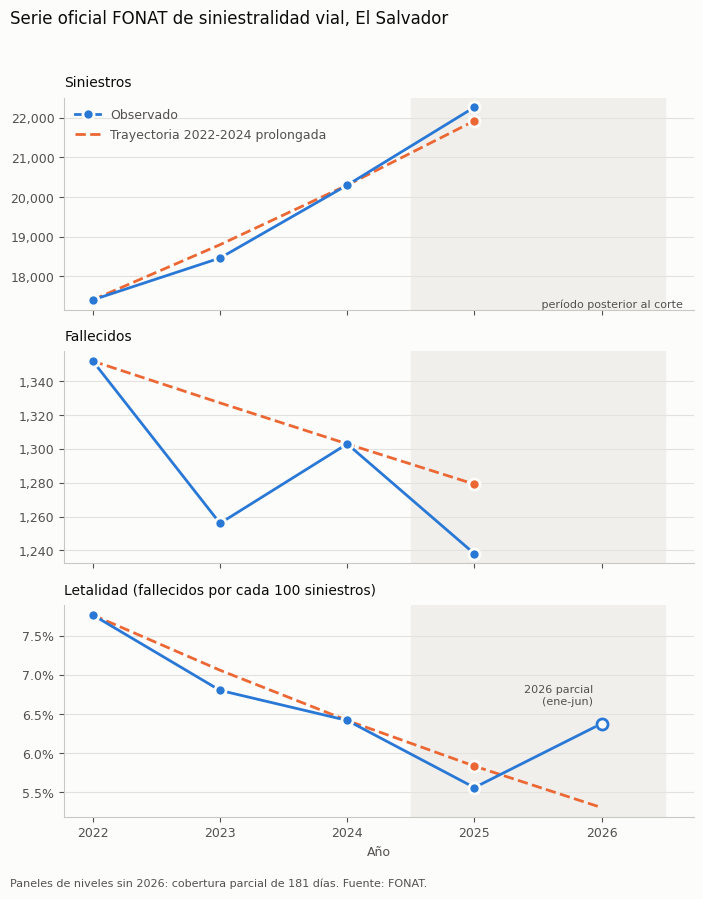


Figura escrita en reports/figures/nb06_01_serie_oficial.png


In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

METRICAS_SERIE = {
    "siniestros": "Siniestros",
    "fallecidos": "Fallecidos",
    "letalidad_pct": "Letalidad (fallecidos por cada 100 siniestros)",
}
PARES = [(2022, 2023), (2023, 2024), (2022, 2024)]

# ----------------------------------------------------- 5.1 variacion interanual
inter = SERIE[list(METRICAS_SERIE)].pct_change() * 100
inter.columns = [f"var_{c}_pct" for c in inter.columns]
# El nivel de 2026 no es comparable: su variacion de nivel queda vacia.
inter.loc[2026, ["var_siniestros_pct", "var_fallecidos_pct"]] = np.nan
inter["nota"] = np.where(inter.index == 2026, "letalidad parcial; niveles vacios", "")

print("5.1  Variacion interanual")
print(inter.to_string(float_format=lambda v: f"{v:9.4f}", na_rep="vacio"))

# --------------------------------------------- 5.2 trayectoria previa 2022-2024
def tasa_par(s: pd.Series, a0: int, a1: int) -> float:
    """Tasa anual compuesta entre dos anios."""
    return (s.loc[a1] / s.loc[a0]) ** (1 / (a1 - a0)) - 1

tend = pd.DataFrame(
    {f"{a0}-{a1}": {m: 100 * tasa_par(SERIE[m], a0, a1) for m in METRICAS_SERIE}
     for a0, a1 in PARES}
)
tend["rango_pp"] = tend.max(axis=1) - tend.min(axis=1)

print("\n\n5.2  Tasa anual implicita por cada par de anios previos, en porcentaje")
print(tend.to_string(float_format=lambda v: f"{v:9.4f}"))
print("\nEl par 2022-2024 es el promedio geometrico de los dos anteriores.")
print("Ajustar una recta OLS sobre los logaritmos de los tres anios devuelve")
print("ese mismo valor: con tres puntos equiespaciados el del medio no entra")
print("en la pendiente.")

# --------------------------- 5.3 observado contra la prolongacion de esa tendencia
filas = []
for m in METRICAS_SERIE:
    comparables = [2025] if m != "letalidad_pct" else [2025, 2026]
    for anio in comparables:
        obs = float(SERIE.loc[anio, m])
        for a0, a1 in PARES:
            g = tasa_par(SERIE[m], a0, a1)
            proy = float(SERIE.loc[2024, m] * (1 + g) ** (anio - 2024))
            filas.append({
                "metrica": m, "anio": anio, "tasa_base": f"{a0}-{a1}",
                "g_pct": 100 * g, "proyectado": proy, "observado": obs,
                "brecha_pct": 100 * (obs - proy) / proy,
                "nota": "letalidad parcial ene-jun" if anio == 2026 else "",
            })

BRECHA = pd.DataFrame(filas)
print("\n\n5.3  Observado contra la prolongacion de la trayectoria previa")
print(BRECHA.to_string(index=False, float_format=lambda v: f"{v:11.4f}"))

RESUMEN = (BRECHA.groupby(["metrica", "anio"])["brecha_pct"]
                 .agg(brecha_min="min", brecha_max="max")
                 .assign(amplitud_pp=lambda d: d["brecha_max"] - d["brecha_min"]))
print("\nAmplitud de la brecha segun cual de las tres tasas previas se use:")
print(RESUMEN.to_string(float_format=lambda v: f"{v:11.4f}"))

print("\nNiveles de 2026 no comparados: cobertura de 181 dias contra anios completos.")

# ------------------------------------------------------------- 5.4 figura
AZUL, NARANJA = "#2a78d6", "#eb6834"      # paleta validada, superficie clara
TINTA, TINTA2 = "#0b0b0b", "#52514e"

fig, axes = plt.subplots(3, 1, figsize=(7.2, 9.0), sharex=True)
fig.patch.set_facecolor("#fcfcfb")

for ax, (col, titulo) in zip(axes, METRICAS_SERIE.items()):
    ax.set_facecolor("#fcfcfb")
    es_letalidad = col == "letalidad_pct"
    anios_obs = [2022, 2023, 2024, 2025] + ([2026] if es_letalidad else [])
    y_obs = SERIE.loc[anios_obs, col].to_numpy(dtype=float)

    # region posterior al corte, sin fecha precisa
    ax.axvspan(2024.5, 2026.5, color="#f0efec", zorder=0)

    ax.plot(anios_obs, y_obs, color=AZUL, lw=2, marker="o", ms=8,
            mec="#fcfcfb", mew=2, label="Observado", zorder=3)

    if es_letalidad:   # 2026 es parcial: marca hueca
        ax.plot([2026], [y_obs[-1]], marker="o", ms=8, mfc="#fcfcfb",
                mec=AZUL, mew=2, ls="none", zorder=4)
        ax.annotate("2026 parcial\n(ene-jun)", (2026, y_obs[-1]),
                    textcoords="offset points", xytext=(-6, 14),
                    ha="right", fontsize=8, color=TINTA2)

    g = tasa_par(SERIE[col], 2022, 2024)
    anios_tend = [2022, 2023, 2024, 2025] + ([2026] if es_letalidad else [])
    y_tend = [float(SERIE.loc[2022, col]) * (1 + g) ** (a - 2022) for a in anios_tend]
    ax.plot(anios_tend, y_tend, color=NARANJA, lw=2, ls="--",
            label="Trayectoria 2022-2024 prolongada", zorder=2)
    ax.plot([2025], [y_tend[3]], marker="o", ms=8, color=NARANJA,
            mec="#fcfcfb", mew=2, ls="none", zorder=2)

    ax.set_title(titulo, fontsize=10, color=TINTA, loc="left", pad=8)
    ax.grid(axis="y", color="#e3e2de", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color("#c9c8c3")
    ax.tick_params(colors=TINTA2, labelsize=9)
    if not es_letalidad:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    else:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1f}%"))

axes[0].legend(frameon=False, fontsize=9, loc="upper left", labelcolor=TINTA2)
axes[-1].set_xticks([2022, 2023, 2024, 2025, 2026])
axes[-1].set_xlabel("Año", fontsize=9, color=TINTA2)
axes[0].text(2025.5, axes[0].get_ylim()[0], " período posterior al corte",
             fontsize=8, color=TINTA2, va="bottom")

fig.suptitle("Serie oficial FONAT de siniestralidad vial, El Salvador",
             fontsize=12, color=TINTA, x=0.02, ha="left", y=0.98)
fig.text(0.02, 0.005,
         "Paneles de niveles sin 2026: cobertura parcial de 181 días. Fuente: FONAT.",
         fontsize=8, color=TINTA2, ha="left")
fig.tight_layout(rect=[0, 0.02, 1, 0.96])

SALIDA_FIG = RAIZ / "reports" / "figures" / "nb06_01_serie_oficial.png"
fig.savefig(SALIDA_FIG, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f"\nFigura escrita en {SALIDA_FIG.relative_to(RAIZ)}")

## 6. Pronóstico contrafactual desde el modelo calibrado

El Random Forest de NB05 se ajustó sobre 2022 a 2024 y nunca vio el período
posterior. Aplicarlo a las filas de 2025 y del primer semestre de 2026, con el
calendario, el clima y la estructura territorial reales de esas fechas, produce
el conteo que el modelo espera si el riesgo por unidad de exposición se hubiera
mantenido en el nivel del período previo. Eso es el contrafactual.

### Qué agrega y qué no

Conviene ser preciso sobre esto, porque es fácil presentarlo como una segunda
confirmación independiente y no lo es. El nivel anual del contrafactual está
gobernado por el mismo mecanismo que la prolongación de tendencia ya calculada:
un crecimiento compuesto de 7.84% anual, estimado sobre los años de
entrenamiento. La tasa que sale de la serie oficial entre 2022 y 2024 es de
7.99%. Son el mismo supuesto con dos calibraciones ligeramente distintas, no
dos caminos separados que coinciden.

Lo que el modelo agrega son dos cosas concretas.

La primera es una escala de error. La prolongación aritmética de una tendencia
de tres puntos no viene con ninguna medida de cuánto puede equivocarse. El
modelo sí: NB05 documentó un sigma de calibración de 0.04 y una deriva a
dieciocho meses de -0.0432 sobre este mismo horizonte. Esas dos cifras dicen
cuánto se mueve el pronóstico por razones internas al modelo, sin que pase nada
en el mundo.

La segunda es que permite comparar 2026. Las filas de 2026 en la matriz cubren
exactamente los mismos 181 días que el registro oficial publicado, de enero a
junio. El contrafactual se calcula sobre esas filas y no sobre un año completo,
así que ambos lados de la comparación tienen la misma cobertura. Esa
comparación no estaba disponible trabajando solo con los agregados anuales.

### Umbral de detección, declarado antes de medir

Con las dos cifras de validación de NB05 se fijan dos umbrales, y se fijan acá,
antes de calcular la brecha, para que el criterio no quede acomodado al
resultado.

El umbral mínimo es el mayor de los dos, 4.32%. Una diferencia entre
contrafactual y observado por debajo de ese valor es indistinguible del error
propio del modelo y no se interpreta.

El umbral conservador suma la deriva sistemática y el sigma, 8.32%. Una
diferencia por encima de ese valor excede lo que la validación de NB05
documenta como error del modelo.

Entre ambos umbrales la lectura queda como ambigua, sin forzar una
interpretación en ninguna dirección.

### Alcance

El contrafactual se calcula únicamente para siniestros. No hay uno para
fallecidos. El clasificador de severidad disponible alcanzó un f1 macro de
0.3247 y una exactitud de 0.3940 en NB04, está ajustado sobre la matriz
anterior y no sobre la v2, y un contrafactual de mortalidad construido sobre
ese desempeño sería menos informativo que no construirlo.

Tampoco se leen los residuos dentro del año, ni por mes, ni por día de semana,
ni por distrito. Comparar el modelo contra la distribución intra-anual de la
matriz mide la diferencia entre el modelo y el generador sintético, no entre el
modelo y el registro real, que es la razón por la que el análisis se apoya en
los totales anuales.

In [16]:
# ----------------------------------------- 6.1 contrafactual sobre el post-corte
POST = MATRIZ[MATRIZ["split"] == "test"].copy()
POST["cf"] = RF.predict(construir_X(POST))

CF = POST.groupby("anio").agg(
    contrafactual=("cf", "sum"),
    matriz=("n_siniestros", "sum"),
    dias=("fecha", "nunique"),
)
CF["oficial"] = OFICIAL["siniestros"].reindex(CF.index)
CF["cobertura"] = OFICIAL["cobertura"].reindex(CF.index)

print("6.1  Contrafactual anual de siniestros")
print(CF[["contrafactual", "matriz", "oficial", "dias", "cobertura"]].to_string(
    float_format=lambda v: f"{v:12.1f}"))

# La matriz reproduce el oficial exactamente, verificado al construir la serie.
print(f"\nmatriz igual a oficial en el post-corte: "
      f"{bool((CF['matriz'] == CF['oficial']).all())}")

# ------------------------------------------ 6.2 umbrales, fijados antes de medir
UMBRAL_MIN = 100 * max(SIGMA_RF, abs(DERIVA_RF))
UMBRAL_CONS = 100 * (abs(DERIVA_RF) + SIGMA_RF)

print(f"\n\n6.2  Umbrales de deteccion derivados de la validacion de NB05")
print(f"  sigma de calibracion        : {100*SIGMA_RF:.2f}%")
print(f"  deriva a 18 meses           : {100*DERIVA_RF:+.2f}%")
print(f"  umbral minimo (el mayor)    : {UMBRAL_MIN:.2f}%")
print(f"  umbral conservador (suma)   : {UMBRAL_CONS:.2f}%")

# -------------------------------------------- 6.3 agregado sobre todo el horizonte
cf_total = float(POST["cf"].sum())
obs_total = float(POST["n_siniestros"].sum())
print(f"\n\n6.3  Horizonte completo 2025-01-01 a 2026-06-30")
print(f"  contrafactual : {cf_total:,.1f}")
print(f"  observado     : {obs_total:,.0f}")
print(f"  razon cf/obs  : {cf_total/obs_total:.6f}")
print(f"  calibracion documentada en NB05 sobre el mismo periodo: {CALIB_RF}")

CF_ANUAL = CF[["contrafactual", "oficial", "dias", "cobertura"]].copy()

6.1  Contrafactual anual de siniestros
      contrafactual  matriz  oficial  dias          cobertura
anio                                                         
2025        22497.1   22265    22265   365           completo
2026        11469.4   11509    11509   181  parcial (ene-jun)

matriz igual a oficial en el post-corte: True


6.2  Umbrales de deteccion derivados de la validacion de NB05
  sigma de calibracion        : 4.00%
  deriva a 18 meses           : -4.32%
  umbral minimo (el mayor)    : 4.32%
  umbral conservador (suma)   : 8.32%


6.3  Horizonte completo 2025-01-01 a 2026-06-30
  contrafactual : 33,966.4
  observado     : 33,774
  razon cf/obs  : 1.005698
  calibracion documentada en NB05 sobre el mismo periodo: 1.0057


## 7. Observado contra contrafactual

El contrafactual dice cuántos siniestros esperaba el modelo bajo las
condiciones del período previo. El registro oficial dice cuántos hubo. Esta
sección mide la diferencia entre ambos y la lee contra los umbrales fijados
antes de calcularla.

### Cómo se mide

La diferencia se expresa como porcentaje sobre el contrafactual, no sobre lo
observado, porque el contrafactual es la referencia contra la que se compara.
Se reporta también en número de siniestros, que es la unidad en la que la cifra
significa algo fuera del notebook.

Los dos períodos se miden por separado. El de 2025 cubre el año completo. El de
2026 cubre los 181 días de enero a junio en ambos lados de la comparación, así
que es una comparación válida aunque no sea un año.

### Cómo se lee

Se aplica el criterio de tres tramos ya fijado. Por debajo de 4.32% la
diferencia queda dentro de lo que el propio modelo se mueve y no se interpreta.
Entre 4.32% y 8.32% queda como ambigua. Por encima de 8.32% excede el error que
la validación de NB05 documenta.

Para que los porcentajes no queden abstractos, se reporta cuántos siniestros
representa el umbral mínimo en cada período. Es la cantidad que tendría que
haberse apartado el registro para que la diferencia fuera legible con este
instrumento.

### Contra la prolongación aritmética

Se pone al lado la brecha que resultó de prolongar la tendencia de la serie
oficial, con sus tres tasas base. No es una verificación cruzada: ambos
procedimientos descansan sobre el mismo supuesto de crecimiento compuesto
estimado en los años previos, como quedó dicho al construir el contrafactual.
Se muestran juntas para ver si el instrumento más elaborado se aparta del más
simple, no para que uno confirme al otro.

### La figura

Se produce `nb06_02_contrafactual.png`. El eje vertical es la desviación
porcentual respecto del contrafactual, lo que permite poner los dos períodos en
la misma escala pese a que uno es un año y el otro medio. Las dos bandas
horizontales son los umbrales, y la línea de cero es el contrafactual mismo.

### Lo que esta sección no establece

Una diferencia de cualquier magnitud entre contrafactual y observado no es un
efecto de la ley. El período posterior contiene todo lo que ocurrió en él, y el
crecimiento del parque vehicular, que este proyecto no tiene medido, actúa
sobre la misma serie y en la misma dirección que cualquier otra cosa que haya
cambiado.

7.1  Observado contra contrafactual
      contrafactual  oficial  brecha_siniestros   brecha_pct  umbral_min_siniestros          cobertura                      lectura
anio                                                                                                                               
2025       22497.10    22265            -232.10        -1.03                 971.87           completo  dentro del error del modelo
2026       11469.35    11509              39.65         0.35                 495.48  parcial (ene-jun)  dentro del error del modelo

Umbrales aplicados: minimo 4.32%, conservador 8.32%
  2025: la diferencia tendria que superar 972 siniestros para ser legible
  2026: la diferencia tendria que superar 495 siniestros para ser legible


7.2  Siniestros 2025 por los dos procedimientos
  prolongacion aritmetica de la serie oficial:
tasa_base       g_pct  proyectado   observado  brecha_pct
2022-2023      6.0604  21531.3283  22265.0000      3.4075
2023-2024      9.9550 

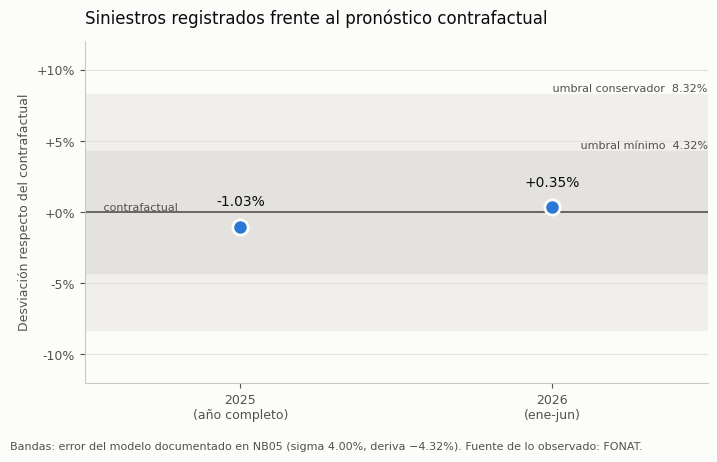


Figura escrita en reports/figures/nb06_02_contrafactual.png


In [17]:
# ------------------------------------------------- 7.1 brecha contra contrafactual
GAP = CF_ANUAL.copy()
GAP["brecha_pct"] = 100 * (GAP["oficial"] - GAP["contrafactual"]) / GAP["contrafactual"]
GAP["brecha_siniestros"] = GAP["oficial"] - GAP["contrafactual"]
GAP["umbral_min_siniestros"] = GAP["contrafactual"] * UMBRAL_MIN / 100


def clasificar(pct: float) -> str:
    a = abs(pct)
    if a < UMBRAL_MIN:
        return "dentro del error del modelo"
    if a < UMBRAL_CONS:
        return "ambiguo"
    return "excede el error documentado"


GAP["lectura"] = GAP["brecha_pct"].map(clasificar)

print("7.1  Observado contra contrafactual")
print(GAP[["contrafactual", "oficial", "brecha_siniestros", "brecha_pct",
           "umbral_min_siniestros", "cobertura", "lectura"]].to_string(
    float_format=lambda v: f"{v:12.2f}"))

print(f"\nUmbrales aplicados: minimo {UMBRAL_MIN:.2f}%, conservador {UMBRAL_CONS:.2f}%")
for anio, fila in GAP.iterrows():
    print(f"  {anio}: la diferencia tendria que superar "
          f"{fila['umbral_min_siniestros']:,.0f} siniestros para ser legible")

# ----------------------------------- 7.2 al lado de la prolongacion aritmetica
cmp_sin = BRECHA[(BRECHA["metrica"] == "siniestros") & (BRECHA["anio"] == 2025)]
print("\n\n7.2  Siniestros 2025 por los dos procedimientos")
print("  prolongacion aritmetica de la serie oficial:")
print(cmp_sin[["tasa_base", "g_pct", "proyectado", "observado", "brecha_pct"]].to_string(
    index=False, float_format=lambda v: f"{v:11.4f}"))
print(f"\n  contrafactual del modelo: proyectado {GAP.loc[2025, 'contrafactual']:11.4f}   "
      f"observado {GAP.loc[2025, 'oficial']:11.0f}   brecha {GAP.loc[2025, 'brecha_pct']:8.4f}")
print("\n  Ambos descansan sobre el mismo supuesto de crecimiento compuesto")
print("  estimado en los anios previos. No son procedimientos independientes.")

# --------------------------------------------------------------- 7.3 figura
etiquetas = {2025: "2025\n(año completo)", 2026: "2026\n(ene-jun)"}
x = np.arange(len(GAP))
y = GAP["brecha_pct"].to_numpy()

fig, ax = plt.subplots(figsize=(7.2, 4.6))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.axhspan(-UMBRAL_CONS, UMBRAL_CONS, color="#f0efec", zorder=0)
ax.axhspan(-UMBRAL_MIN, UMBRAL_MIN, color="#e3e2de", zorder=1)
ax.axhline(0, color="#52514e", lw=1.2, zorder=2)

ax.plot(x, y, ls="none", marker="o", ms=11, color=AZUL,
        mec="#fcfcfb", mew=2, zorder=4)
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:+.2f}%", (xi, yi), textcoords="offset points",
                xytext=(0, 15), ha="center", fontsize=10, color=TINTA)

ax.text(len(GAP) - 0.5, UMBRAL_MIN, f" umbral mínimo  {UMBRAL_MIN:.2f}%",
        va="bottom", ha="right", fontsize=8, color=TINTA2)
ax.text(len(GAP) - 0.5, UMBRAL_CONS, f" umbral conservador  {UMBRAL_CONS:.2f}%",
        va="bottom", ha="right", fontsize=8, color=TINTA2)
ax.text(-0.45, 0, " contrafactual", va="bottom", ha="left", fontsize=8, color=TINTA2)

ax.set_xticks(x)
ax.set_xticklabels([etiquetas[a] for a in GAP.index], fontsize=9, color=TINTA2)
ax.set_xlim(-0.5, len(GAP) - 0.5)
lim = max(UMBRAL_CONS * 1.45, float(np.abs(y).max()) * 1.6)
ax.set_ylim(-lim, lim)
ax.set_ylabel("Desviación respecto del contrafactual", fontsize=9, color=TINTA2)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.0f}%"))
ax.grid(axis="y", color="#e3e2de", lw=0.8, zorder=0)
ax.set_axisbelow(True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
for lado in ("left", "bottom"):
    ax.spines[lado].set_color("#c9c8c3")
ax.tick_params(colors=TINTA2, labelsize=9)

ax.set_title("Siniestros registrados frente al pronóstico contrafactual",
             fontsize=12, color=TINTA, loc="left", pad=12)
fig.text(0.01, 0.01,
         "Bandas: error del modelo documentado en NB05 (sigma 4.00%, deriva −4.32%). "
         "Fuente de lo observado: FONAT.",
         fontsize=8, color=TINTA2, ha="left")
fig.tight_layout(rect=[0, 0.04, 1, 1])

SALIDA_FIG2 = RAIZ / "reports" / "figures" / "nb06_02_contrafactual.png"
fig.savefig(SALIDA_FIG2, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f"\nFigura escrita en {SALIDA_FIG2.relative_to(RAIZ)}")

### 7.4 Resultado de la comparación

En 2025 se registraron 232 siniestros menos que los 22,497 del contrafactual,
una desviación de -1.03%. En el primer semestre de 2026 se registraron 40 más
que los 11,469 esperados, +0.35%. Las dos quedan por debajo del umbral mínimo
de 4.32%, y por bastante: para volverse legibles con este instrumento, las
diferencias tendrían que haber sido de 972 y 495 siniestros respectivamente.

La prolongación aritmética de la serie oficial ubicó 2025 entre -0.26% y +3.41%
según qué par de años se tomara como base. El contrafactual del modelo da
-1.03%, dentro de ese mismo terreno. La coincidencia no agrega respaldo, porque
los dos procedimientos comparten el supuesto de crecimiento compuesto.

Lo que queda establecido es acotado y conviene enunciarlo con precisión. El
conteo de siniestros del período posterior no se aparta de lo que proyectaba la
trayectoria previa por un margen que este instrumento pueda distinguir de su
propio error. Eso no es evidencia de que la ley no haya tenido efecto. La
resolución del instrumento es de alrededor de cuatro puntos porcentuales, y
cualquier efecto de menor magnitud queda por debajo de lo que puede verse.

La comparación cubre siniestros. La letalidad, que es donde las dos series
oficiales se mueven en direcciones distintas, no tiene contrafactual porque no
hay un modelo de severidad con desempeño suficiente para construirlo.